# More Gibbs Sampler Examples

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

## Probit Regression

Consider the frogs dataset that we previously used to illustrate Logistic Regression. Here we apply fit the probit regression model to this data. 

In [2]:
frogs = pd.read_csv("frogs.csv")

# Design matrix
X = frogs[['altitude','distance','NoOfPools','NoOfSites','avrain','meanmin','meanmax']].copy()
X['distance'] = np.log(X['distance'])
X['NoOfPools'] = np.log(X['NoOfPools'])
X = sm.add_constant(X)
y = frogs['pres.abs'].values

The GLM function in statsmodels can be used to fit the probit model. 

In [ ]:
# GLM (probit + logit)
print(sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.Probit())).fit().summary())
print(sm.GLM(y, X, family=sm.families.Binomial()).fit().summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  212
Model:                            GLM   Df Residuals:                      204
Model Family:                Binomial   Df Model:                            7
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -99.536
Date:                Mon, 06 Apr 2026   Deviance:                       199.07
Time:                        18:01:24   Pearson chi2:                     229.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3173
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.9617     73.193      0.560      0.5

Below is the code for the Gibbs sampler. We are using augmentation and sampling from the joint posterior of $w, \beta$ given the data. Here $w_i 
\overset{\text{i.i.d}}{\sim} N(x_i^T \beta, 1)$ and $y_i = I\{w_i > 0\}$. The conditional distribution of $\beta$ given $w$ and the data is
\begin{align*}
   \beta \mid w, \text{data} \sim N((X^T X)^{-1} X^T w, (X^T X)^{-1}). 
\end{align*}
The conditional distribution of $w$ given $\beta$ and the data is: 
\begin{align*}
   w_i \overset{\text{independent}}{\sim} N(x_i^T \beta, 1) \text{ truncated to } I\{w_i > 0\} = y_i. 
\end{align*}
In other words, if $y_i = 1$, then $w_i$ is distributed as $N(x_i^T \beta, 1)$ conditioned to be positive. And if $y_i = 0$, then $w_i$ is distributed as $N(x_i^T \beta, 1)$ conditioned to be negative. Simulating from the truncated normal distribution can be done as described in https://en.wikipedia.org/wiki/Truncated_normal_distribution#Generating_values_from_the_truncated_normal_distribution.  

In [3]:
from scipy.stats import norm

In [4]:
Xm = X.values
linmod_cov = np.linalg.inv(Xm.T @ Xm)
n, p = Xm.shape
XtX_inv = linmod_cov
Xt = Xm.T
A = XtX_inv @ Xt   # (X^T X)^{-1} X^T

beta_init = A @ y
w_init = Xm @ beta_init
state = np.concatenate([beta_init, w_init])

nit = 100000
path = np.zeros((nit, p+n))
path[0] = state

for t in range(1, nit):
    if np.random.rand() < 0.5:
        #this part updates beta and leaves w fixed
        w = state[p:]
        beta = A @ w  
        path[t,:p] = np.random.multivariate_normal(beta, XtX_inv)
        path[t,p:] = w
    else:
        #this part updates w and leaves beta fixed
        beta = state[:p]
        path[t,:p] = beta

        mu = Xm @ beta   # vectorized
        u = np.random.rand(n)

        mask1 = (y == 1)
        mask0 = ~mask1

        path[t,p:][mask1] = mu[mask1] + norm.ppf(
            u[mask1] + (1-u[mask1])*norm.cdf(-mu[mask1])
        )
        path[t,p:][mask0] = mu[mask0] + norm.ppf(
            u[mask0]*norm.cdf(-mu[mask0])
        )

    state = path[t]
    if t % 2000 == 0: print(t)

2000
4000
6000
8000
10000
12000
14000
16000
18000
20000
22000
24000
26000
28000
30000
32000
34000
36000
38000
40000
42000
44000
46000
48000
50000
52000
54000
56000
58000
60000
62000
64000
66000
68000
70000
72000
74000
76000
78000
80000
82000
84000
86000
88000
90000
92000
94000
96000
98000


Below we compute the posterior means and standard deviations. 

In [5]:
# Posterior summaries
pth = pd.DataFrame(path[:, :p], columns=[f'b{i}' for i in range(p)])
bayes = pd.DataFrame({
    'est': pth.mean(),
    'std.err': pth.std()
})

print(bayes)

          est    std.err
b0  37.945838  74.321427
b1  -0.007769   0.021400
b2  -0.432785   0.143967
b3   0.352205   0.123884
b4   0.003225   0.062940
b5  -0.010914   0.034947
b6   3.143699   0.882286
b7  -2.385674   2.741282


Below we compare the posterior means and standard deviations, with the frequentist estimates and standard errors. Remember that the frequentist estimates and standard errors coincide with the Bayesian solution corresponding to the Laplace posterior normal approximation. 

In [6]:
# GLM (probit)
glm_res = sm.GLM(
    y, Xm,
    family=sm.families.Binomial(link=sm.families.links.Probit())
).fit()

# Combine results
comp = pd.DataFrame({
    'Bayes_est': bayes['est'].values,
    'GLM_est': glm_res.params,
    'Bayes_se': bayes['std.err'].values,
    'GLM_se': glm_res.bse
}, index=[f'b{i}' for i in range(len(glm_res.params))])

print(comp)

    Bayes_est    GLM_est   Bayes_se     GLM_se
b0  37.945838  40.961673  74.321427  73.192736
b1  -0.007769  -0.009011   0.021400   0.021139
b2  -0.432785  -0.417042   0.143967   0.144002
b3   0.352205   0.339612   0.123884   0.121531
b4   0.003225   0.004392   0.062940   0.062026
b5  -0.010914  -0.010206   0.034947   0.034128
b6   3.143699   2.965350   0.882286   0.862714
b7  -2.385674  -2.436715   2.741282   2.700422


It is clear that the Gibbs sampler gives very similar results to those obtained by the Laplace posterior normal approximation. 

## Simulation Setting

The following simulation setting uses a very small sample size $n = 15$. Here there will be more discrepancy between the Gibbs sampler and the Laplace posterior normal approximation. 

In [7]:
n = 15
beta_0 = -4.0
beta_1 = 0.8

# for reproducibility
np.random.seed(42)

# generate x
x = np.random.normal(loc=5, scale=0.75, size=n)

# compute probit probabilities
probs = norm.cdf(beta_0 + beta_1 * x)

# generate y
y = np.random.binomial(1, probs, size=n)

print("x =", x)
print("p =", probs)
print("y =", y)

x = [5.37253561 4.89630177 5.4857664  6.14227239 4.82438497 4.82439728
 6.18440961 5.57557605 4.64789421 5.40692003 4.65243673 4.65070268
 5.1814717  3.56503982 3.70631163]
p = [0.61715929 0.46694224 0.65121882 0.81959373 0.44413563 0.44413952
 0.82831502 0.67740726 0.38909267 0.62761229 0.39048675 0.38995441
 0.55771458 0.12549086 0.15034597]
y = [1 0 1 1 0 1 1 1 0 1 0 0 1 1 1]


Below we compute the Laplace posterior normal approximation (i.e., the frequentist estimates and standard errors). 

In [8]:
# design matrix with intercept
X = sm.add_constant(x)

# fit probit regression
model = sm.GLM(
    y,
    X,
    family=sm.families.Binomial(link=sm.families.links.Probit())
)

result = model.fit()

print(result.summary())
print("\nEstimated coefficients:")
print("beta_0_hat =", result.params[0])
print("beta_1_hat =", result.params[1])

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   15
Model:                            GLM   Df Residuals:                       13
Model Family:                Binomial   Df Model:                            1
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8.9535
Date:                Mon, 13 Jul 2026   Deviance:                       17.907
Time:                        15:40:04   Pearson chi2:                     14.1
No. Iterations:                     5   Pseudo R-squ. (CS):            0.07617
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2020      2.453     -0.898      0.3

Next we implement the Gibbs sampler. 

In [9]:
n, p = X.shape
linmod_cov = np.linalg.inv(X.T @ X)
print(linmod_cov)


[[ 3.28868367 -0.64340466]
 [-0.64340466  0.12848149]]


In [10]:
Xm = X
XtX_inv = linmod_cov
Xt = Xm.T
A = XtX_inv @ Xt   # (X^T X)^{-1} X^T

beta_init = A @ y
w_init = Xm @ beta_init
state = np.concatenate([beta_init, w_init])

nit = 500000
path = np.zeros((nit, p+n))
path[0] = state

for t in range(1, nit):
    if np.random.rand() < 0.5:
        w = state[p:]
        beta = A @ w  
        path[t,:p] = np.random.multivariate_normal(beta, XtX_inv)
        path[t,p:] = w
    else:
        beta = state[:p]
        path[t,:p] = beta

        mu = Xm @ beta   # vectorized
        u = np.random.rand(n)

        mask1 = (y == 1)
        mask0 = ~mask1

        path[t,p:][mask1] = mu[mask1] + norm.ppf(
            u[mask1] + (1-u[mask1])*norm.cdf(-mu[mask1])
        )
        path[t,p:][mask0] = mu[mask0] + norm.ppf(
            u[mask0]*norm.cdf(-mu[mask0])
        )

    state = path[t]
    if t % 2000 == 0: print(t)

2000
4000
6000
8000
10000
12000
14000
16000
18000
20000
22000
24000
26000
28000
30000
32000
34000
36000
38000
40000
42000
44000
46000
48000
50000
52000
54000
56000
58000
60000
62000
64000
66000
68000
70000
72000
74000
76000
78000
80000
82000
84000
86000
88000
90000
92000
94000
96000
98000
100000
102000
104000
106000
108000
110000
112000
114000
116000
118000
120000
122000
124000
126000
128000
130000
132000
134000
136000
138000
140000
142000
144000
146000
148000
150000
152000
154000
156000
158000
160000
162000
164000
166000
168000
170000
172000
174000
176000
178000
180000
182000
184000
186000
188000
190000
192000
194000
196000
198000
200000
202000
204000
206000
208000
210000
212000
214000
216000
218000
220000
222000
224000
226000
228000
230000
232000
234000
236000
238000
240000
242000
244000
246000
248000
250000
252000
254000
256000
258000
260000
262000
264000
266000
268000
270000
272000
274000
276000
278000
280000
282000
284000
286000
288000
290000
292000
294000
296000
298000
300000
302

Below are the posterior means and standard errors (after removing a burnin). 

In [11]:
# Posterior summaries with burn-in
burnin = 5000

pth = pd.DataFrame(path[burnin:, :p], columns=[f'b{i}' for i in range(p)])
bayes = pd.DataFrame({
    'est': pth.mean(),
    'std.err': pth.std()
})

print(bayes)

         est   std.err
b0 -2.376084  2.530925
b1  0.580168  0.517387


Below we print the posteior means and standard errors side by side with the frequentist estimates and standard errors. 

In [12]:
# GLM (probit)
glm_res = sm.GLM(
    y, Xm,
    family=sm.families.Binomial(link=sm.families.links.Probit())
).fit()

# Combine results
comp = pd.DataFrame({
    'Bayes_est': bayes['est'].values,
    'GLM_est': glm_res.params,
    'Bayes_se': bayes['std.err'].values,
    'GLM_se': glm_res.bse
}, index=[f'b{i}' for i in range(len(glm_res.params))])

print(comp)

    Bayes_est   GLM_est  Bayes_se    GLM_se
b0  -2.376084 -2.201963  2.530925  2.453266
b1   0.580168  0.535108  0.517387  0.492885


Which of these two outputs better approximates the true posterior? This question is harder to answer in general but since this is a scenario with only two parameters, we can attempt to compute the actual posterior using a dense grid-based numerical approximation. We do this below. 


Grid posterior summaries:
Posterior mean beta_0 = -2.371029301192905
Posterior sd   beta_0 = 2.5215968840131504
Posterior mean beta_1 = 0.5788161540054723
Posterior sd   beta_1 = 0.5159341483896761


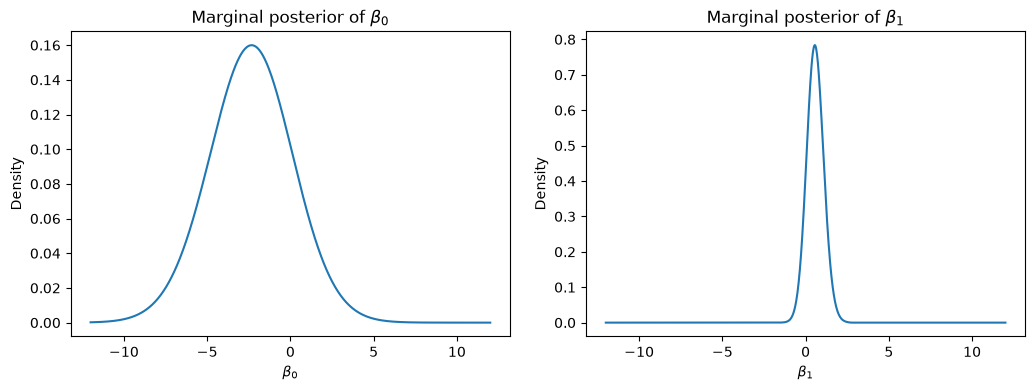

In [13]:
from scipy.special import logsumexp
# -----------------------------
# Grid posterior computation
# -----------------------------

# center grid around MLE
b0_hat, b1_hat = result.params
se0, se1 = result.bse

# choose a grid range (we are placing the grid around a large range)
b0_grid = np.linspace(-12.0, 12.0, 1000)
b1_grid = np.linspace(-12.0, 12.0, 1000)

B0, B1 = np.meshgrid(b0_grid, b1_grid, indexing="xy")

log_post = np.zeros_like(B0)

# compute log-likelihood on the grid
for i in range(len(b1_grid)):
    for j in range(len(b0_grid)):
        beta = np.array([B0[i, j], B1[i, j]])
        eta = X @ beta
        p = norm.cdf(eta)

        # avoid log(0)
        p = np.clip(p, 1e-14, 1 - 1e-14)

        loglik = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
        log_post[i, j] = loglik   # flat prior => log posterior = log likelihood + constant

# normalize numerically
log_post_norm = log_post - logsumexp(log_post)
post = np.exp(log_post_norm)

# account for grid cell area so posterior integrates to about 1
db0 = b0_grid[1] - b0_grid[0]
db1 = b1_grid[1] - b1_grid[0]
post = post / (post.sum() * db0 * db1)

# -----------------------------
# Posterior summaries from grid
# -----------------------------
# marginals
post_b0 = post.sum(axis=0) * db1
post_b1 = post.sum(axis=1) * db0

# posterior means
mean_b0 = np.sum(b0_grid * post_b0) * db0
mean_b1 = np.sum(b1_grid * post_b1) * db1

# posterior variances
var_b0 = np.sum((b0_grid - mean_b0)**2 * post_b0) * db0
var_b1 = np.sum((b1_grid - mean_b1)**2 * post_b1) * db1

print("\nGrid posterior summaries:")
print("Posterior mean beta_0 =", mean_b0)
print("Posterior sd   beta_0 =", np.sqrt(var_b0))
print("Posterior mean beta_1 =", mean_b1)
print("Posterior sd   beta_1 =", np.sqrt(var_b1))

# -----------------------------
# Plots
# -----------------------------
plt.figure(figsize=(15, 4))

# marginal for beta_0
plt.subplot(1, 3, 2)
plt.plot(b0_grid, post_b0)
plt.xlabel(r'$\beta_0$')
plt.ylabel("Density")
plt.title(r"Marginal posterior of $\beta_0$")

# marginal for beta_1
plt.subplot(1, 3, 3)
plt.plot(b1_grid, post_b1)
plt.xlabel(r'$\beta_1$')
plt.ylabel("Density")
plt.title(r"Marginal posterior of $\beta_1$")

plt.tight_layout()
plt.show()

Below we plot all the estimates (and standard errors) side-by-side for comparison. 

In [14]:
comp = pd.DataFrame({
    'Bayes_est': bayes['est'].values[:2],
    'GLM_est': glm_res.params[:2],
    'Grid_est': [mean_b0, mean_b1],
    'Bayes_se': bayes['std.err'].values[:2],
    'GLM_se': glm_res.bse[:2],
    'Grid_se': [np.sqrt(var_b0), np.sqrt(var_b1)]
}, index=['b0', 'b1'])

print(comp)

    Bayes_est   GLM_est  Grid_est  Bayes_se    GLM_se   Grid_se
b0  -2.376084 -2.201963 -2.371029  2.530925  2.453266  2.521597
b1   0.580168  0.535108  0.578816  0.517387  0.492885  0.515934


It is clear the Gibbs sampler and grid-based posterior answers are very close to each other. This indicates that the Gibbs sampler is a much better approximation for the actual posterior. 